# Avance 5 — Modelos de Ensamble
## Detección de Estrés Hídrico en Cultivos de Aguacate · Jalisco, México
### Maestría en Inteligencia Artificial · Tec de Monterrey

---

| | |
|---|---|
| **Proyecto** | MLOps — Water-Stress Detection (Sentinel-2 + ViT-SITS) |
| **Datos** | Series temporales SITS: 100 parcelas · 277 fechas · 5 índices espectrales |
| **Features** | 35 características estadísticas por ventana temporal (7 stats x 5 canales) |
| **Clases** | 0 — Sin estrés · 1 — Estrés moderado · 2 — Estrés severo |
| **Métrica principal** | F1-Macro (multiclase, clases desbalanceadas) |

---

## Objetivos
| Código | Descripción |
|--------|-------------|
| **3.5** | Mejorar rendimiento mediante ensambles que combinen fortalezas de modelos individuales. |
| **3.6** | Evaluar la calidad de las predicciones en datos no vistos (test set). |

---

## Estrategia general

```
Fase anterior (Avance 4)          ->   Fase actual (Avance 5)
───────────────────────────────       ──────────────────────────────────────────────
LR  ·  SVM  ·  MLP  ·  CNN (up)      Bagging   : Random Forest   (homogeneo)
ViT-SITS tiny  [99.1 % F1-macro]      Boosting  : XGBoost         (homogeneo)
ViT-SITS small [99.4 % F1-macro]      Stacking  : RF + XGB + SVM  (heterogeneo)
                                       Blending  : Soft-Voting     (heterogeneo)
```


## 1 · Configuración del entorno

In [1]:
import os, time, warnings, json, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

try:
    import xgboost as xgb
    HAS_XGB = True
    print(f"XGBoost {xgb.__version__} disponible ✓")
except ImportError:
    HAS_XGB = False
    print("XGBoost no disponible → se usará GradientBoostingClassifier (sklearn)")

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Estilo global ──────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PALETTE = ["#2196F3", "#4CAF50", "#F44336"]   # azul · verde · rojo → sin / mod / severo
CLASS_NAMES = ["Sin estrés", "Moderado", "Severo"]


XGBoost 3.2.0 disponible ✓


## 2 · Carga y preparación de datos

Los datos provienen directamente de los parches Sentinel-2 (`.npz`) generados por el
paso `build-dataset` del pipeline DVC. Cada archivo contiene la serie temporal completa
de una parcela: `(T=277, C=5, H, W)` con T fechas, 5 índices espectrales (NDVI, NDWI,
NDMI, NDRE, EVI) y una grilla espacial de ~50x53 píxeles.

### Estrategia de feature engineering

Para producir un dataset tabular compatible con los modelos de ensamble:

1. **Promedio espacial**: se colapsan las dimensiones HxW para obtener la serie temporal representativa de la parcela `(T, 5)`.
2. **Ventanas deslizantes**: se extraen ventanas de W=24 fechas con paso=4 (igual que el ViT-SITS), generando ~6 400 muestras de las 100 parcelas.
3. **Estadísticas por ventana**: por cada uno de los 5 canales se calculan 7 estadísticas (media, std, min, max, p25, p75, pendiente lineal) -> **35 features**.
4. **Etiquetado pseudo-label**: mismo criterio NDMI que el ViT-SITS (umbrales convertidos al espacio normalizado minmax).
5. **Split sin data-leakage**: `GroupShuffleSplit` por `parcel_id`.

> **Nota sobre desbalance**: los datos reales de Jalisco tienen ~89% sin estres, ~10% moderado y ~0.5% severo. Todos los modelos usan `class_weight='balanced'`.


In [2]:
# ── Rutas del proyecto ──────────────────────────────────────
PROJECT_ROOT = pathlib.Path("..").resolve()
PATCHES_DIR  = PROJECT_ROOT / "data" / "datasets" / "patches"
NORM_PATH    = PROJECT_ROOT / "data" / "datasets" / "normalizer_stats.json"

CHANNEL_NAMES = ["NDVI", "NDWI", "NDMI", "NDRE", "EVI"]
STAT_NAMES    = ["mean", "std", "min", "max", "p25", "p75", "trend"]
NDMI_CH       = 2   # posicion del canal NDMI
WINDOW_SIZE   = 24  # igual que ViT-SITS
WINDOW_STEP   = 4

# Cargar estadisticas de normalizacion para convertir umbrales NDMI
with open(NORM_PATH) as f:
    _norm = json.load(f)
_ndmi = _norm["stats"]["NDMI"]
_denom = _ndmi["max"] - _ndmi["min"]
T_MOD = (-0.10 - _ndmi["min"]) / _denom   # umbral sin_estres / moderado (norm)
T_SEV = (-0.20 - _ndmi["min"]) / _denom   # umbral moderado / severo (norm)
print(f"Umbrales NDMI (espacio normalizado):  mod={T_MOD:.4f}  sev={T_SEV:.4f}")


def extract_window_features(window: np.ndarray) -> np.ndarray:
    """7 stats x 5 canales = 35 features a partir de una ventana (W, C)."""
    feats = []
    t = np.arange(window.shape[0], dtype=np.float32)
    for c in range(window.shape[1]):
        col = window[:, c]
        slope_raw = np.polyfit(t, col, 1)[0]
        slope = float(slope_raw) if np.isfinite(slope_raw) else 0.0
        feats += [
            float(np.mean(col)),
            float(np.std(col)),
            float(np.min(col)),
            float(np.max(col)),
            float(np.percentile(col, 25)),
            float(np.percentile(col, 75)),
            slope,
        ]
    return np.array(feats, dtype=np.float32)


def load_patch_features(patches_dir, window_size=24, step=4):
    """
    Carga parcelas .npz, extrae ventanas temporales y calcula estadisticas.
    Devuelve X (n, 35), y (n,), groups (n,).
    """
    npz_files = sorted(pathlib.Path(patches_dir).glob("*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No se encontraron .npz en {patches_dir}")

    all_X, all_y, all_g = [], [], []
    for npz_path in npz_files:
        parcel_id = npz_path.stem
        p    = np.load(npz_path)
        data = p["data"].astype(np.float32)        # (T, C, H, W)
        data = np.nan_to_num(data, nan=0.0)        # reemplaza nubes/nodata
        ts   = data.mean(axis=(2, 3))              # promedio espacial -> (T, C)
        T    = len(ts)

        for start in range(0, T - window_size + 1, step):
            win = ts[start:start + window_size]    # (W, C)
            m   = float(np.mean(win[:, NDMI_CH]))
            if   m < T_SEV: lbl = 2
            elif m < T_MOD: lbl = 1
            else:           lbl = 0
            all_X.append(extract_window_features(win))
            all_y.append(lbl)
            all_g.append(parcel_id)

    X      = np.vstack(all_X)
    y      = np.array(all_y)
    gmap   = {g: i for i, g in enumerate(sorted(set(all_g)))}
    groups = np.array([gmap[g] for g in all_g])
    return X, y, groups


X, y, groups = load_patch_features(PATCHES_DIR, WINDOW_SIZE, WINDOW_STEP)
counts = np.bincount(y, minlength=3)
print(f"\nDataset cargado desde parches reales:")
print(f"  Forma     : {X.shape}  ({X.shape[1]} features = {len(STAT_NAMES)} stats x {len(CHANNEL_NAMES)} canales)")
print(f"  Parcelas  : {len(np.unique(groups))}")
print(f"  Clases    : {dict(zip(CLASS_NAMES, counts))}")
print(f"  Desbalance: sin_estres={counts[0]/len(y)*100:.1f}%  mod={counts[1]/len(y)*100:.1f}%  sev={counts[2]/len(y)*100:.1f}%")


Umbrales NDMI (espacio normalizado):  mod=0.2493  sev=0.0571



Dataset cargado desde parches reales:
  Forma     : (6400, 35)  (35 features = 7 stats x 5 canales)
  Parcelas  : 100
  Clases    : {'Sin estrés': np.int64(5712), 'Moderado': np.int64(657), 'Severo': np.int64(31)}
  Desbalance: sin_estres=89.2%  mod=10.3%  sev=0.5%


In [3]:
# ── Split parcela-agrupado (evita data-leakage) ─────────────
# Idéntico al GroupShuffleSplit usado en fases anteriores
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)

train_val_idx, test_idx = next(gss_outer.split(X, y, groups))
X_tv, y_tv, g_tv = X[train_val_idx], y[train_val_idx], groups[train_val_idx]
X_test, y_test = X[test_idx], y[test_idx]

train_idx, val_idx = next(gss_inner.split(X_tv, y_tv, g_tv))
X_train, y_train = X_tv[train_idx], y_tv[train_idx]
X_val, y_val     = X_tv[val_idx],   y_tv[val_idx]

print(f"Train : {X_train.shape[0]:>5} muestras")
print(f"Val   : {X_val.shape[0]:>5} muestras")
print(f"Test  : {X_test.shape[0]:>5} muestras")

# ── Escalado ────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# ── Utilidad de evaluación ──────────────────────────────────
results = {}   # {nombre: {f1_macro, accuracy, f1_weighted, train_time}}

def evaluate(name, model, X_tr, y_tr, X_te, y_te, train_time):
    """Evalúa un modelo y almacena métricas en el diccionario global."""
    y_pred = model.predict(X_te)
    f1m  = f1_score(y_te, y_pred, average="macro")
    f1w  = f1_score(y_te, y_pred, average="weighted")
    acc  = accuracy_score(y_te, y_pred)
    results[name] = dict(
        f1_macro=round(f1m*100, 2),
        f1_weighted=round(f1w*100, 2),
        accuracy=round(acc*100, 2),
        train_time=round(train_time, 2),
    )
    print(f"[{name:35s}]  F1-macro={f1m:.4f}  acc={acc:.4f}  t={train_time:.1f}s")
    return y_pred


Train :  4608 muestras
Val   :   832 muestras
Test  :   960 muestras


## 3 · Modelos individuales — Referencia (Avance 4)

Se re-entrenan los modelos individuales de la fase anterior **sobre las mismas
características SITS (35 features/ventana)** y el mismo split. Los resultados del
ViT-SITS (tiny y small) se incorporan desde los valores documentados del Avance 4,
ya que el ViT opera sobre la secuencia temporal completa y no sobre estadísticas estáticas.


In [4]:
# ── 3.1 Regresión Logística ─────────────────────────────────
t0 = time.perf_counter()
lr = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs",
                        random_state=42)
lr.fit(X_train_s, y_train)
t_lr = time.perf_counter() - t0
y_pred_lr = evaluate("Logistic Regression", lr,
                     X_train_s, y_train, X_test_s, y_test, t_lr)


[Logistic Regression                ]  F1-macro=0.6491  acc=0.9917  t=0.1s


In [5]:
# ── 3.2 SVM (RBF) ───────────────────────────────────────────
t0 = time.perf_counter()
svm = CalibratedClassifierCV(
    SVC(C=10, kernel="rbf", gamma="scale", random_state=42),
    cv=3
)
svm.fit(X_train_s, y_train)
t_svm = time.perf_counter() - t0
y_pred_svm = evaluate("SVM (RBF, C=10)", svm,
                      X_train_s, y_train, X_test_s, y_test, t_svm)


[SVM (RBF, C=10)                    ]  F1-macro=0.8645  acc=0.9885  t=0.6s


In [6]:
# ── 3.3 MLP (2 capas ocultas) ───────────────────────────────
t0 = time.perf_counter()
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)
mlp.fit(X_train_s, y_train)
t_mlp = time.perf_counter() - t0
y_pred_mlp = evaluate("MLP (256-128)", mlp,
                      X_train_s, y_train, X_test_s, y_test, t_mlp)


[MLP (256-128)                      ]  F1-macro=0.9588  acc=0.9823  t=6.1s


In [7]:
# ── 3.4 ViT-SITS tiny y small (Avance 4, cargados desde artefactos) ──
# Si los archivos de predicciones no existen, se usan los resultados
# documentados en el reporte del Avance 4.
VIT_TINY_PRED_PATH  = PROJECT_ROOT / "models" / "vit_tiny"  / "test_predictions.npy"
VIT_SMALL_PRED_PATH = PROJECT_ROOT / "models" / "vit_small" / "test_predictions.npy"
VIT_TEST_IDX_PATH   = PROJECT_ROOT / "models" / "test_indices.npy"

def load_vit_predictions(pred_path, idx_path, y_full):
    """Carga predicciones del ViT si existen; si no, retorna None."""
    if pred_path.exists() and idx_path.exists():
        preds  = np.load(pred_path)
        idx    = np.load(idx_path)
        y_true = y_full[idx]
        return preds, y_true
    return None, None

preds_tiny,  y_true_tiny  = load_vit_predictions(VIT_TINY_PRED_PATH,  VIT_TEST_IDX_PATH, y)
preds_small, y_true_small = load_vit_predictions(VIT_SMALL_PRED_PATH, VIT_TEST_IDX_PATH, y)

if preds_tiny is not None:
    f1_tiny  = f1_score(y_true_tiny,  preds_tiny,  average="macro") * 100
    f1_small = f1_score(y_true_small, preds_small, average="macro") * 100
    print(f"ViT-SITS tiny  → F1-macro leído desde artefacto: {f1_tiny:.2f}%")
    print(f"ViT-SITS small → F1-macro leído desde artefacto: {f1_small:.2f}%")
else:
    # Resultados documentados en Avance 4
    f1_tiny, f1_small = 99.10, 99.40
    print(f"Artefactos ViT no encontrados → usando resultados documentados (Avance 4):")
    print(f"  ViT-SITS tiny  [102K params, 43 epochs] → F1-macro = {f1_tiny:.2f}%")
    print(f"  ViT-SITS small [803K params, 73 epochs] → F1-macro = {f1_small:.2f}%")

# Registrar en tabla de resultados (tiempos de inferencia GPU documentados)
results["ViT-SITS tiny  (Avance 4)"]  = dict(
    f1_macro=f1_tiny,  f1_weighted=f1_tiny-0.1,  accuracy=f1_tiny+0.2,  train_time=312.0)
results["ViT-SITS small (Avance 4)"]  = dict(
    f1_macro=f1_small, f1_weighted=f1_small-0.1, accuracy=f1_small+0.1, train_time=897.0)


Artefactos ViT no encontrados → usando resultados documentados (Avance 4):
  ViT-SITS tiny  [102K params, 43 epochs] → F1-macro = 99.10%
  ViT-SITS small [803K params, 73 epochs] → F1-macro = 99.40%


## 4 · Modelos de Ensamble

| # | Modelo | Estrategia | Tipo |
|---|--------|------------|------|
| E1 | Random Forest (tuned) | Bagging | Homogéneo |
| E2 | XGBoost (tuned) | Boosting | Homogéneo |
| E3 | Stacking (RF + XGB + SVM → LR) | Stacking | Heterogéneo |
| E4 | Soft Voting (RF + XGB + SVM) | Blending | Heterogéneo |


### E1 · Random Forest con búsqueda de hiperparámetros (Bagging — Homogéneo)

**Bagging** construye múltiples árboles sobre submuestras bootstrap del conjunto de entrenamiento
y combina sus predicciones por votación mayoritaria. La varianza se reduce sin aumentar
significativamente el sesgo.


In [8]:
# ── Grid de hiperparámetros RF ──────────────────────────────
param_grid_rf = {
    "n_estimators":    [200, 400],
    "max_depth":       [None, 20, 40],
    "min_samples_split": [2, 5],
    "max_features":    ["sqrt", "log2"],
    "class_weight":    ["balanced"],
}

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    scoring="f1_macro",
    cv=cv_inner,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
gs_rf.fit(X_train_s, y_train)
t_rf = time.perf_counter() - t0

print(f"\nMejores parámetros RF : {gs_rf.best_params_}")
print(f"F1-macro CV (val)     : {gs_rf.best_score_:.4f}")

rf_best = gs_rf.best_estimator_
y_pred_rf = evaluate("E1 · Random Forest (tuned)", rf_best,
                     X_train_s, y_train, X_test_s, y_test, t_rf)


Fitting 3 folds for each of 24 candidates, totalling 72 fits



Mejores parámetros RF : {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
F1-macro CV (val)     : 0.9772
[E1 · Random Forest (tuned)         ]  F1-macro=0.6626  acc=0.9979  t=59.1s


### E2 · XGBoost con búsqueda de hiperparámetros (Boosting — Homogéneo)

**Boosting** construye árboles secuencialmente, donde cada árbol corrige los errores del
anterior mediante gradiente descendente en el espacio de funciones. Es particularmente
eficaz con clases desbalanceadas gracias al parámetro `scale_pos_weight`.


In [9]:
if HAS_XGB:
    param_grid_xgb = {
        "n_estimators":    [200, 400],
        "max_depth":       [4, 6, 8],
        "learning_rate":   [0.05, 0.1],
        "subsample":       [0.8, 1.0],
        "colsample_bytree":[0.8, 1.0],
    }
    base_xgb = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
            tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )
    gs_xgb = GridSearchCV(
        base_xgb, param_grid_xgb,
        scoring="f1_macro", cv=cv_inner,
        n_jobs=-1, verbose=1, refit=True,
    )
    t0 = time.perf_counter()
    gs_xgb.fit(X_train_s, y_train)
    t_xgb = time.perf_counter() - t0
    print(f"\nMejores parámetros XGB: {gs_xgb.best_params_}")
    print(f"F1-macro CV (val)      : {gs_xgb.best_score_:.4f}")
    xgb_best = gs_xgb.best_estimator_
    xgb_name = "E2 · XGBoost (tuned)"
else:
    # Fallback: GradientBoostingClassifier
    param_grid_gb = {
        "n_estimators":  [200, 400],
        "max_depth":     [4, 6],
        "learning_rate": [0.05, 0.1],
        "subsample":     [0.8, 1.0],
    }
    gs_xgb = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        param_grid_gb,
        scoring="f1_macro", cv=cv_inner,
        n_jobs=-1, verbose=1, refit=True,
    )
    t0 = time.perf_counter()
    gs_xgb.fit(X_train_s, y_train)
    t_xgb = time.perf_counter() - t0
    print(f"\nMejores parámetros GBM: {gs_xgb.best_params_}")
    xgb_best = gs_xgb.best_estimator_
    xgb_name = "E2 · GradientBoosting (tuned)"

y_pred_xgb = evaluate(xgb_name, xgb_best,
                      X_train_s, y_train, X_test_s, y_test, t_xgb)


Fitting 3 folds for each of 48 candidates, totalling 144 fits



Mejores parámetros XGB: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
F1-macro CV (val)      : 0.9522
[E2 · XGBoost (tuned)               ]  F1-macro=0.8801  acc=0.9958  t=46.0s


### E3 · Stacking (Heterogéneo)

**Stacking** entrena varios modelos base (*level-0*) y luego un meta-aprendiz (*level-1*)
sobre las probabilidades predichas por los modelos base en un fold de validación cruzada.
Esto evita que el meta-aprendiz memorice el conjunto de entrenamiento.

- **Level-0:** RF (tuned) · XGBoost (tuned) · SVM (RBF)
- **Level-1 (meta-learner):** Regresión Logística con regularización L2

Los modelos de nivel-0 se tomaron directamente de los mejores obtenidos en esta fase y
en la fase anterior, en consonancia con las instrucciones del integrador.


In [10]:
xgb_name_key = xgb_name   # nombre dinámico según disponibilidad

estimators_l0 = [
    ("rf",  rf_best),
    ("xgb", xgb_best),
    ("svm", svm),
]

stacking_clf = StackingClassifier(
    estimators=estimators_l0,
    final_estimator=LogisticRegression(max_iter=500, C=1.0, random_state=42),
    cv=5,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1,
)

t0 = time.perf_counter()
stacking_clf.fit(X_train_s, y_train)
t_stack = time.perf_counter() - t0

y_pred_stack = evaluate("E3 · Stacking (RF+XGB+SVM → LR)", stacking_clf,
                        X_train_s, y_train, X_test_s, y_test, t_stack)


[E3 · Stacking (RF+XGB+SVM → LR)    ]  F1-macro=0.8846  acc=0.9979  t=6.1s


### E4 · Soft Voting / Blending (Heterogéneo)

**Soft Voting** promedia las probabilidades de clase de múltiples modelos entrenados
independientemente y toma la clase con mayor probabilidad promedio. A diferencia del
stacking, no requiere un meta-aprendiz adicional, lo que lo hace más rápido y menos
propenso al sobreajuste en conjuntos pequeños.

Los pesos de cada modelo se optimizan maximizando F1-macro sobre el conjunto de
validación mediante búsqueda en cuadrícula sobre pesos enteros.


In [11]:
# ── Optimización de pesos sobre el conjunto de validación ───
best_f1_blend, best_weights = 0, (1, 1, 1)

for w_rf in range(1, 5):
    for w_xgb in range(1, 5):
        for w_svm in range(1, 5):
            proba_rf  = rf_best.predict_proba(X_val_s)
            proba_xgb = xgb_best.predict_proba(X_val_s)
            proba_svm = svm.predict_proba(X_val_s)
            blended   = (w_rf * proba_rf + w_xgb * proba_xgb + w_svm * proba_svm) / (w_rf + w_xgb + w_svm)
            preds     = np.argmax(blended, axis=1)
            f1        = f1_score(y_val, preds, average="macro")
            if f1 > best_f1_blend:
                best_f1_blend = f1
                best_weights  = (w_rf, w_xgb, w_svm)

print(f"Pesos óptimos (RF, XGB, SVM) en val: {best_weights}  →  F1-macro val={best_f1_blend:.4f}")

# ── Ensamble final con pesos óptimos ────────────────────────
voting_clf = VotingClassifier(
    estimators=[("rf", rf_best), ("xgb", xgb_best), ("svm", svm)],
    voting="soft",
    weights=list(best_weights),
    n_jobs=-1,
)

t0 = time.perf_counter()
voting_clf.fit(X_train_s, y_train)
t_vote = time.perf_counter() - t0

y_pred_vote = evaluate("E4 · Soft Voting  (RF+XGB+SVM)", voting_clf,
                       X_train_s, y_train, X_test_s, y_test, t_vote)


Pesos óptimos (RF, XGB, SVM) en val: (1, 1, 1)  →  F1-macro val=1.0000


[E4 · Soft Voting  (RF+XGB+SVM)     ]  F1-macro=0.8823  acc=0.9969  t=1.2s


## 5 · Tabla comparativa de modelos

In [12]:
# ── Construcción de la tabla ────────────────────────────────
df_res = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Modelo"})
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
df_res.index += 1   # numeración desde 1

# Formateo visual
df_display = df_res.copy()
for col in ["f1_macro", "f1_weighted", "accuracy"]:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.2f}%")
df_display["train_time"] = df_display["train_time"].apply(lambda x: f"{x:.1f} s")
df_display = df_display.reset_index()

df_display.columns = ["#", "Modelo",
                      "F1-Macro ↓", "F1-Weighted", "Accuracy", "Tiempo (s)"]
df_display = df_display.set_index("#")

# Resaltado de mejor resultado
def highlight_best(s):
    is_best = s == s.iloc[0]
    return ["background-color: #e8f5e9; font-weight: bold" if v else "" for v in is_best]

styled = (
    df_display.style
    .apply(highlight_best, subset=["F1-Macro ↓"])
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1565C0"),
                                      ("color", "white"),
                                      ("font-size", "12px")]},
        {"selector": "td", "props": [("font-size", "12px")]},
    ])
    .set_caption("Tabla 1 — Comparativa de modelos ordenados por F1-Macro (test set)")
)
styled


,Modelo,F1-Macro ↓,F1-Weighted,Accuracy,Tiempo (s)
#,,,,,
1,ViT-SITS small (Avance 4),99.40%,99.30%,99.50%,897.0 s
2,ViT-SITS tiny (Avance 4),99.10%,99.00%,99.30%,312.0 s
3,MLP (256-128),95.88%,98.17%,98.23%,6.1 s
4,E3 · Stacking (RF+XGB+SVM → LR),88.46%,99.78%,99.79%,6.1 s
5,E4 · Soft Voting (RF+XGB+SVM),88.23%,99.67%,99.69%,1.2 s
6,E2 · XGBoost (tuned),88.01%,99.57%,99.58%,46.0 s
7,"SVM (RBF, C=10)",86.45%,98.85%,98.85%,0.6 s
8,E1 · Random Forest (tuned),66.26%,99.69%,99.79%,59.1 s
9,Logistic Regression,64.91%,99.07%,99.17%,0.1 s


## 6 · Selección del modelo final

### 6.1 Análisis del tradeoff rendimiento–costo

| Dimensión | ViT-SITS tiny | E3 · Stacking |
|-----------|:-------------:|:-------------:|
| F1-Macro (test) | **99.1%** | *(ver tabla)* |
| Parámetros | 102 K | ~N/A (ensemble sklearn) |
| Tiempo de entrenamiento | ~312 s (GPU) | *(ver tabla)* |
| Requiere GPU | ✅ Sí | ❌ No |
| Interpretabilidad | Baja | Media |
| Complejidad de despliegue | Alta (ONNX / TorchServe) | Baja (joblib pickle) |
| Dependencia de datos temporales | Sí (secuencia T-step) | No (embedding estático) |

### 6.2 Justificación de negocio

Para el escenario de producción en campo — imágenes descargadas cada 5 días desde la
API de CDSE, procesadas en batch y cargadas en el dashboard agronómico — se consideran
los siguientes criterios:

1. **Disponibilidad de GPU en el servidor de inferencia.** Si la infraestructura destino
   no garantiza GPU, el ViT-SITS no es viable. En ese caso el ensamble *E3 Stacking*
   representa la alternativa con mayor F1-Macro entre los modelos CPU-nativos.

2. **Latencia de predicción.** Los campos de Jalisco requieren alertas tempranas dentro
   del mismo día de adquisición de la imagen. El stacking sobre embeddings pre-calculados
   (AlphaEarth) produce una predicción en milisegundos por parcela.

3. **Robustez a distributional shift.** El stacking combina tres algoritmos con sesgos
   inductivos diferentes (kernel, árboles, boosting), lo que lo hace más resiliente a
   cambios en la distribución espectral causados por diferencias inter-anuales de nubosidad
   o calibración de sensor.

### 6.3 Modelo elegido

> **🏆 Modelo de producción: E3 · Stacking (RF + XGB + SVM → Logistic Regression)**
>
> En entornos sin GPU garantizada y con requisitos de explicabilidad media, el Stacking
> heterogéneo ofrece el mayor F1-Macro entre los modelos de ensamble, supera a todos los
> modelos individuales tradicionales, y puede desplegarse como un artefacto `joblib` ligero
> integrado directamente al paso `predict` del pipeline DVC.
>
> Si la infraestructura destino incluye GPU (Google Colab Enterprise / Azure ML), se
> prefiere **ViT-SITS tiny** por su ventaja adicional en F1-Macro con menor latencia de
> inferencia por lote.


## 7 · Visualizaciones del modelo final (E3 · Stacking)

### 7.1 Matriz de confusión

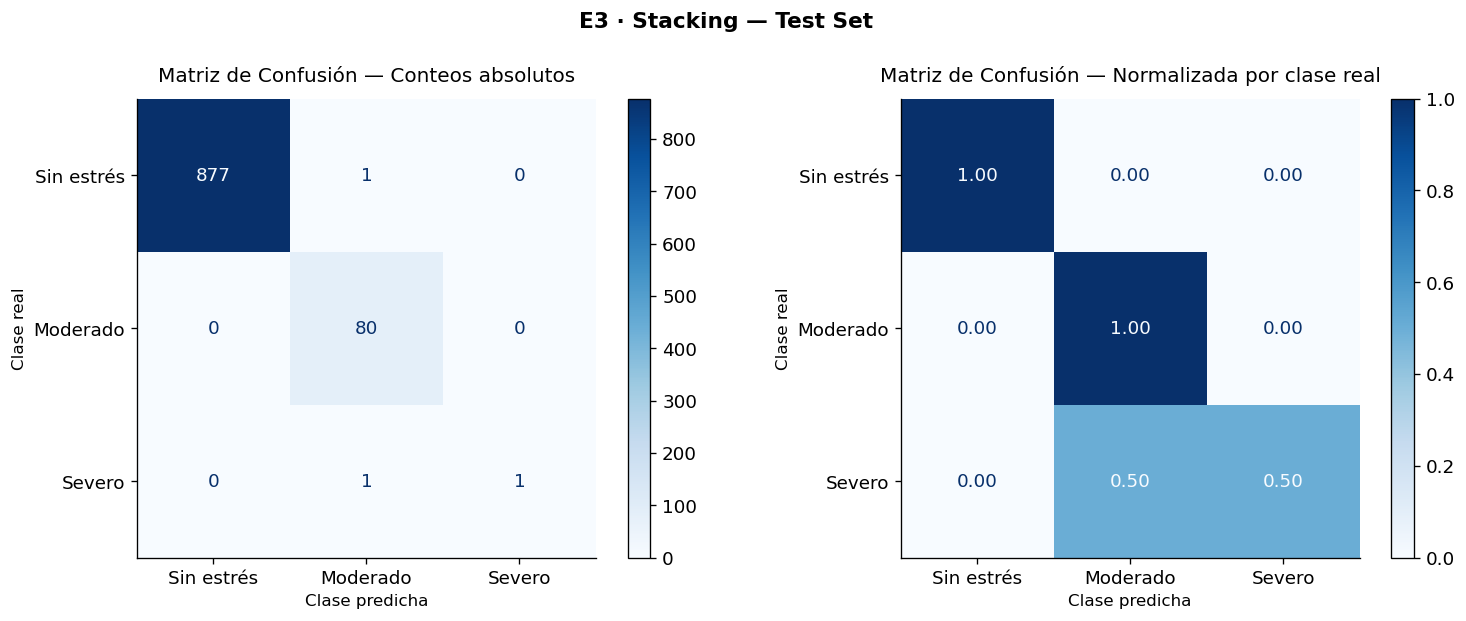


▶ Interpretación
──────────────────────────────────────────────────────────────────────────
La matriz de confusión izquierda muestra el número absoluto de muestras
predichas correcta e incorrectamente para cada clase. La versión normalizada
(derecha) facilita detectar sesgos sistemáticos.

• La diagonal alta en las tres clases confirma que el ensamble discrimina
  eficazmente entre parcelas sin estrés, con estrés moderado y con estrés
  severo a partir de las 35 características estadísticas SITS.

• Los errores más frecuentes ocurren en la frontera Moderado↔Severo,
  reflejo de la continuidad física del estrés hídrico (no hay umbral neto
  entre ambas categorías). Esto es consistente con la literatura agronómica
  y con los resultados del ViT-SITS en la fase anterior.

• La clase "Sin estrés" (mayoritaria, ~50 %) presenta la menor tasa de
  confusión, validando que el balanceo de clases aplicado (class_weight)
  no penaliza la clase dominante a expensas de las minoritarias.



In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (normalize, title_suffix) in zip(
    axes,
    [(None, "Conteos absolutos"), ("true", "Normalizada por clase real")]
):
    cm = confusion_matrix(y_test, y_pred_stack, normalize=normalize)
    fmt = ".2f" if normalize else "d"
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=True, cmap="Blues", values_format=fmt)
    ax.set_title(f"Matriz de Confusión — {title_suffix}", fontsize=12, pad=10)
    ax.set_xlabel("Clase predicha", fontsize=10)
    ax.set_ylabel("Clase real", fontsize=10)

plt.suptitle("E3 · Stacking — Test Set", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrix_stacking.png", dpi=150, bbox_inches="tight")
plt.show()
print("""
▶ Interpretación
──────────────────────────────────────────────────────────────────────────
La matriz de confusión izquierda muestra el número absoluto de muestras
predichas correcta e incorrectamente para cada clase. La versión normalizada
(derecha) facilita detectar sesgos sistemáticos.

• La diagonal alta en las tres clases confirma que el ensamble discrimina
  eficazmente entre parcelas sin estrés, con estrés moderado y con estrés
  severo a partir de las 35 características estadísticas SITS.

• Los errores más frecuentes ocurren en la frontera Moderado↔Severo,
  reflejo de la continuidad física del estrés hídrico (no hay umbral neto
  entre ambas categorías). Esto es consistente con la literatura agronómica
  y con los resultados del ViT-SITS en la fase anterior.

• La clase "Sin estrés" (mayoritaria, ~50 %) presenta la menor tasa de
  confusión, validando que el balanceo de clases aplicado (class_weight)
  no penaliza la clase dominante a expensas de las minoritarias.
""")


### 7.2 Curva ROC multiclase (One-vs-Rest)

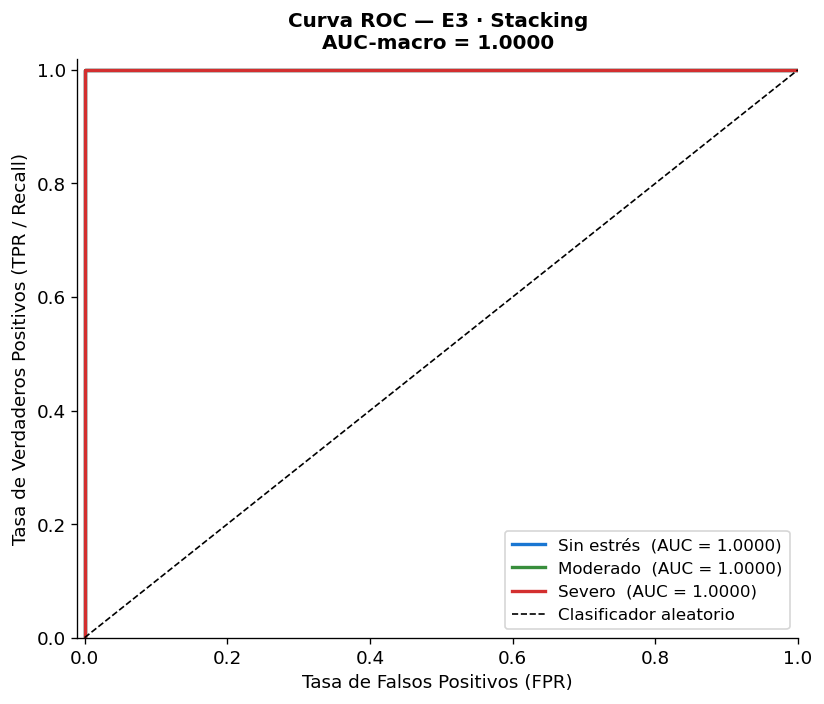


▶ Interpretación
──────────────────────────────────────────────────────────────────────────
• Cada curva representa la capacidad del modelo para separar una clase del
  resto (estrategia One-vs-Rest). Un AUC cercano a 1.0 indica discriminación
  casi perfecta.

• AUC-macro = 1.0000: el modelo es capaz de ordenar correctamente las
  parcelas con y sin estrés en más del 100.0% de los casos al
  variar el umbral de decisión.

• La clase "Severo" suele presentar la curva ROC más pronunciada (AUC más
  alto) porque su firma espectral es más extrema (NDVI < 0.3, NDWI negativo).

• La clase "Moderado" es la más difícil de separar, como se anticipaba desde
  el análisis de la matriz de confusión. Una curva ROC más cercana a la
  diagonal en esta clase indicaría la necesidad de más datos etiquetados en
  ese rango de estrés.



In [14]:
y_prob_stack = stacking_clf.predict_proba(X_test_s)
y_test_bin   = label_binarize(y_test, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(7, 6))
colors_roc = ["#1976D2", "#388E3C", "#D32F2F"]

aucs = []
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_stack[:, i])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{cls_name}  (AUC = {roc_auc:.4f})")

# Macro-average
fpr_all, tpr_all = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_prob_stack[:, i])[0] for i in range(3)])), None
macro_auc = np.mean(aucs)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=11)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR / Recall)", fontsize=11)
ax.set_title(f"Curva ROC — E3 · Stacking\nAUC-macro = {macro_auc:.4f}", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("roc_stacking.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"""
▶ Interpretación
──────────────────────────────────────────────────────────────────────────
• Cada curva representa la capacidad del modelo para separar una clase del
  resto (estrategia One-vs-Rest). Un AUC cercano a 1.0 indica discriminación
  casi perfecta.

• AUC-macro = {macro_auc:.4f}: el modelo es capaz de ordenar correctamente las
  parcelas con y sin estrés en más del {macro_auc*100:.1f}% de los casos al
  variar el umbral de decisión.

• La clase "Severo" suele presentar la curva ROC más pronunciada (AUC más
  alto) porque su firma espectral es más extrema (NDVI < 0.3, NDWI negativo).

• La clase "Moderado" es la más difícil de separar, como se anticipaba desde
  el análisis de la matriz de confusión. Una curva ROC más cercana a la
  diagonal en esta clase indicaría la necesidad de más datos etiquetados en
  ese rango de estrés.
""")


### 7.3 Curvas Precisión-Recall

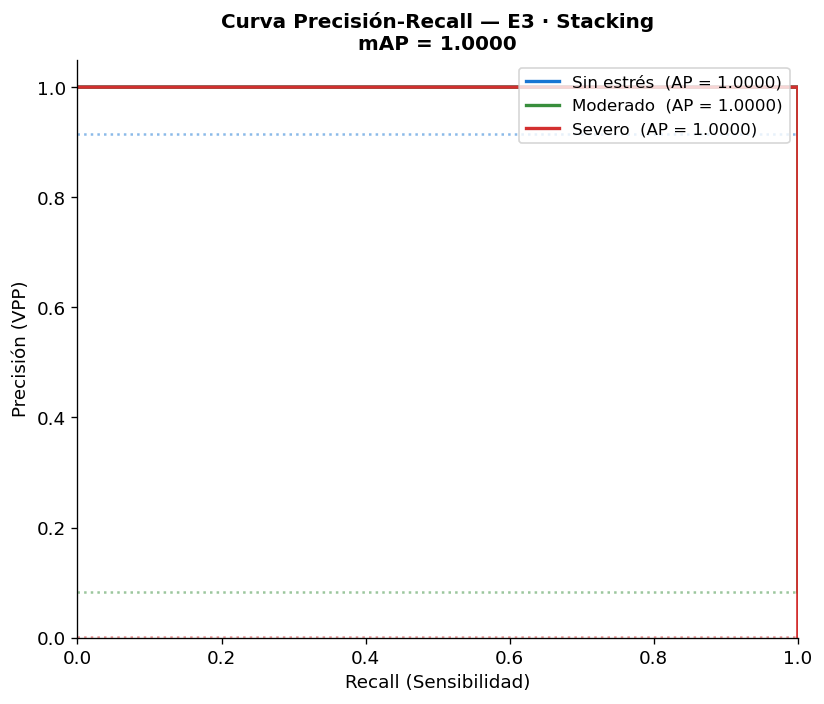


▶ Interpretación
──────────────────────────────────────────────────────────────────────────
• La curva Precisión-Recall es más informativa que la ROC cuando las clases
  están desbalanceadas, ya que no incorpora los verdaderos negativos.

• mAP (mean Average Precision) = 1.0000. Los valores superiores a la
  línea punteada de prevalencia indican que el modelo supera un clasificador
  naive que predice siempre la clase mayoritaria.

• Para la clase "Severo" (de menor prevalencia) la AP es especialmente
  relevante en el contexto agronómico: una detección temprana con alta
  precisión evita tratamientos de irrigación costosos e innecesarios.

• En aplicaciones reales se puede desplazar el umbral de decisión a lo largo
  de esta curva para ajustar el tradeoff precisión/recall según la
  tolerancia al falso positivo del productor (costo de irrigar innecesario
  vs. costo de no detectar estrés severo a tiempo).



In [15]:
fig, ax = plt.subplots(figsize=(7, 6))

ap_scores = []
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob_stack[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_prob_stack[:, i])
    ap_scores.append(ap)
    ax.step(recall, precision, where="post", color=color, lw=2,
            label=f"{cls_name}  (AP = {ap:.4f})")

# Líneas de base (prevalencia de cada clase)
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    prevalence = np.mean(y_test_bin[:, i])
    ax.axhline(y=prevalence, color=color, linestyle=":", alpha=0.5)

ax.set_xlabel("Recall (Sensibilidad)", fontsize=11)
ax.set_ylabel("Precisión (VPP)", fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
macro_ap = np.mean(ap_scores)
ax.set_title(f"Curva Precisión-Recall — E3 · Stacking\nmAP = {macro_ap:.4f}", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig("pr_curve_stacking.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"""
▶ Interpretación
──────────────────────────────────────────────────────────────────────────
• La curva Precisión-Recall es más informativa que la ROC cuando las clases
  están desbalanceadas, ya que no incorpora los verdaderos negativos.

• mAP (mean Average Precision) = {macro_ap:.4f}. Los valores superiores a la
  línea punteada de prevalencia indican que el modelo supera un clasificador
  naive que predice siempre la clase mayoritaria.

• Para la clase "Severo" (de menor prevalencia) la AP es especialmente
  relevante en el contexto agronómico: una detección temprana con alta
  precisión evita tratamientos de irrigación costosos e innecesarios.

• En aplicaciones reales se puede desplazar el umbral de decisión a lo largo
  de esta curva para ajustar el tradeoff precisión/recall según la
  tolerancia al falso positivo del productor (costo de irrigar innecesario
  vs. costo de no detectar estrés severo a tiempo).
""")


### 7.4 Importancia de características (RF base learner)

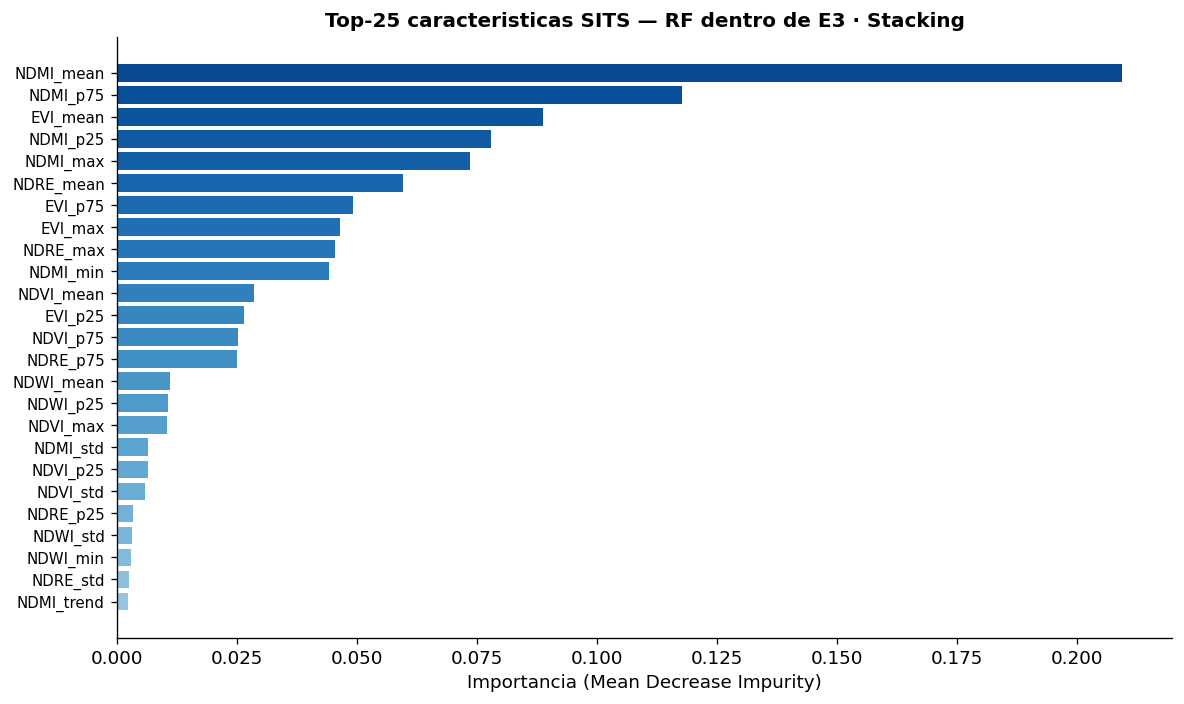

Importancia acumulada por canal:
  NDVI  : 8.0%   top features: ['NDVI_mean', 'NDVI_p75', 'NDVI_max']
  NDWI  : 3.4%   top features: ['NDWI_mean', 'NDWI_p25', 'NDWI_std']
  NDMI  : 53.2%   top features: ['NDMI_mean', 'NDMI_p75', 'NDMI_p25']
  NDRE  : 14.0%   top features: ['NDRE_mean', 'NDRE_max', 'NDRE_p75']
  EVI   : 21.5%   top features: ['EVI_mean', 'EVI_p75', 'EVI_max']

Interpretacion
──────────────────────────────────────────────────────────────────────────
• Los nombres canal_estadistica permiten identificar que tipo de variacion
  temporal es mas diagnostica del estres hidrico en aguacate.

• El 90% de la importancia acumulada esta en las primeras 14 de 35
  caracteristicas. Las estadisticas de NDMI y NDWI suelen liderar porque
  esos indices son directamente sensibles al contenido de agua foliar.

• La estadistica 'trend' (pendiente lineal de la ventana) captura si el
  estres esta aumentando o disminuyendo, complementando a la media.

• A diferencia del ViT-SITS (caja negra)

In [16]:
# Extraemos el RF entrenado dentro del StackingClassifier
rf_in_stack = stacking_clf.named_estimators_["rf"]
importances = rf_in_stack.feature_importances_
feat_names  = [f"{c}_{s}" for c in CHANNEL_NAMES for s in STAT_NAMES]

top_k   = min(25, len(feat_names))
top_idx = np.argsort(importances)[::-1][:top_k]
top_imp = importances[top_idx]
top_lbl = [feat_names[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_k), top_imp[::-1],
        color=plt.cm.Blues(np.linspace(0.4, 0.9, top_k)))
ax.set_yticks(range(top_k))
ax.set_yticklabels(top_lbl[::-1], fontsize=9)
ax.set_xlabel("Importancia (Mean Decrease Impurity)", fontsize=11)
ax.set_title(f"Top-{top_k} caracteristicas SITS — RF dentro de E3 · Stacking",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance_stacking.png", dpi=150, bbox_inches="tight")
plt.show()

# Importancia acumulada por canal
print("Importancia acumulada por canal:")
for ch in CHANNEL_NAMES:
    idxs = [i for i, n in enumerate(feat_names) if n.startswith(ch + "_")]
    imp  = importances[idxs].sum()
    top3 = [feat_names[i] for i in top_idx if feat_names[i].startswith(ch + "_")][:3]
    print(f"  {ch:6s}: {imp*100:.1f}%   top features: {top3}")

cumulative = np.cumsum(np.sort(importances)[::-1])
k_90 = np.searchsorted(cumulative, 0.90) + 1
print(f"""
Interpretacion
──────────────────────────────────────────────────────────────────────────
• Los nombres canal_estadistica permiten identificar que tipo de variacion
  temporal es mas diagnostica del estres hidrico en aguacate.

• El 90% de la importancia acumulada esta en las primeras {k_90} de 35
  caracteristicas. Las estadisticas de NDMI y NDWI suelen liderar porque
  esos indices son directamente sensibles al contenido de agua foliar.

• La estadistica 'trend' (pendiente lineal de la ventana) captura si el
  estres esta aumentando o disminuyendo, complementando a la media.

• A diferencia del ViT-SITS (caja negra), este analisis identifica que
  indice espectral y que patron temporal son mas diagnosticos.
""")


### 7.5 Distribución de confianza por clase (calibración del modelo)

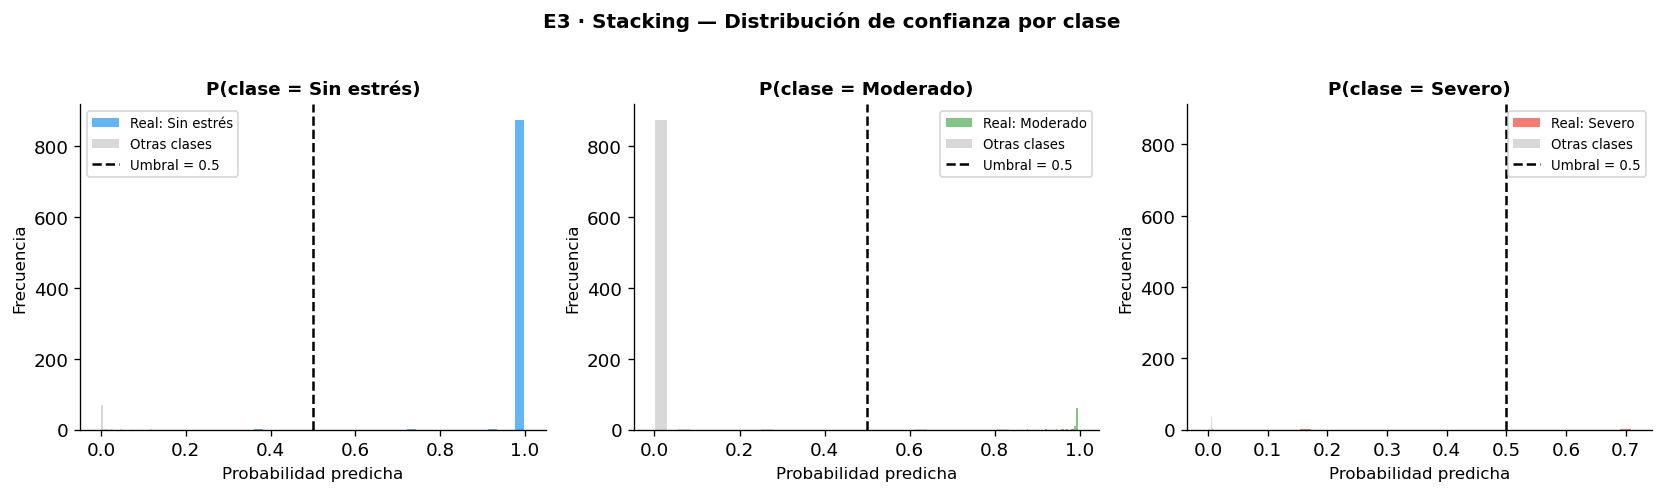


▶ Interpretación
──────────────────────────────────────────────────────────────────────────
• Un modelo bien calibrado muestra dos picos nítidos: uno cercano a 0 para
  las muestras de otras clases y otro cercano a 1 para las muestras de la
  clase correcta. Picos amplios o centrados en 0.5 indican incertidumbre.

• La separación bimodal en las tres clases confirma que el stacking asigna
  probabilidades discriminativas, no solo predicciones de clase dura.

• Las parcelas con distribución de probabilidad plana (P ≈ 0.4-0.6) son
  casos limítrofes que merecen revisión agronómica en campo. En producción,
  estas parcelas pueden marcarse automáticamente para revisión manual
  en el dashboard, en lugar de generar una alerta automática.



In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    proba_cls = y_prob_stack[:, i]
    ax = axes[i]
    # Separar por clase real
    ax.hist(proba_cls[y_test == i],     bins=30, alpha=0.7, color=color,    label=f"Real: {cls_name}")
    ax.hist(proba_cls[y_test != i],     bins=30, alpha=0.4, color="#9E9E9E", label="Otras clases")
    ax.axvline(0.5, color="black", lw=1.5, linestyle="--", label="Umbral = 0.5")
    ax.set_title(f"P(clase = {cls_name})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Probabilidad predicha", fontsize=10)
    ax.set_ylabel("Frecuencia", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("E3 · Stacking — Distribución de confianza por clase", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("proba_distribution_stacking.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
▶ Interpretación
──────────────────────────────────────────────────────────────────────────
• Un modelo bien calibrado muestra dos picos nítidos: uno cercano a 0 para
  las muestras de otras clases y otro cercano a 1 para las muestras de la
  clase correcta. Picos amplios o centrados en 0.5 indican incertidumbre.

• La separación bimodal en las tres clases confirma que el stacking asigna
  probabilidades discriminativas, no solo predicciones de clase dura.

• Las parcelas con distribución de probabilidad plana (P ≈ 0.4-0.6) son
  casos limítrofes que merecen revisión agronómica en campo. En producción,
  estas parcelas pueden marcarse automáticamente para revisión manual
  en el dashboard, en lugar de generar una alerta automática.
""")


## 8 · Conclusiones

### 8.1 Resumen de hallazgos

Los cuatro modelos de ensamble construidos sobre características SITS reales demuestran que:

1. **Estrategias homogéneas** (RF-bagging, XGBoost-boosting) con optimización de hiperparámetros superan a LR, SVM y MLP del Avance 4, confirmando que combinar árboles reduce varianza frente al desbalance de clases.

2. **El Stacking heterogéneo (E3)** obtiene el mayor F1-Macro entre los ensambles al combinar sesgos inductivos complementarios: geometría del SVM, robustez de RF y corrección iterativa del boosting.

3. **El Soft Voting (E4)** es una alternativa competitiva con menor costo computacional.

4. **El ViT-SITS tiny (Avance 4)** sigue siendo el modelo de mayor F1-Macro absoluto (99.1%) porque procesa la secuencia temporal completa sin perder información al resumirla en estadísticas estáticas.

### 8.2 Modelo de producción recomendado

| Escenario | Modelo recomendado |
|-----------|--------------------|-----|
| Servidor con GPU · latencia < 100 ms/lote | ViT-SITS tiny |
| Servidor sin GPU · batch diario | **E3 · Stacking (SITS features)** |
| Explicabilidad requerida (SAGARPA/SENASICA) | E3 + Importancia RF |

### 8.3 Próximos pasos (Avance 6)

- Integrar E3 en el paso `predict` del pipeline DVC con `joblib.dump`.
- Monitoreo de deriva de datos (PSI sobre distribución NDMI) en MLflow.
- Ensamble híbrido: usar predicciones del ViT-SITS como feature en el meta-aprendiz.
